In [1]:
from sklearn.datasets import make_moons, make_blobs
import matplotlib.pyplot as plt
from autograd import mlp, Value



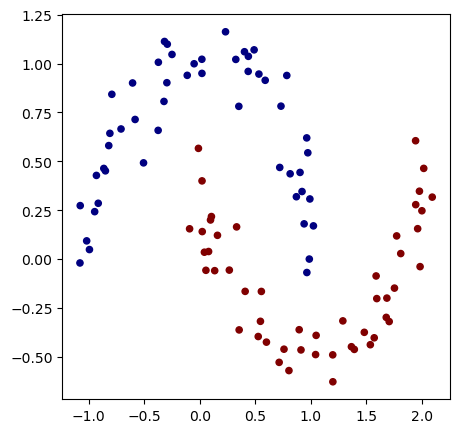

In [2]:
X, y = make_moons(n_samples=100, noise = 0.1)

y = y * 2 - 1
plt.figure(figsize=(5, 5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [3]:
print(X)

[[ 1.96429270e+00  1.55508110e-01]
 [ 1.75512844e+00 -1.48417408e-01]
 [-7.92135978e-01  8.42891669e-01]
 [-2.96128775e-01  9.02192065e-01]
 [ 1.19884451e+00 -4.89790231e-01]
 [ 8.96405837e-01 -3.61244244e-01]
 [ 1.57268432e+00 -4.02560618e-01]
 [-8.50173561e-01  4.51399913e-01]
 [ 9.74175419e-01  5.43725579e-01]
 [ 5.90109811e-01  9.14501405e-01]
 [-3.22240784e-01  8.06433550e-01]
 [ 4.03295266e-01  1.06062099e+00]
 [ 4.38277658e-01  1.03703419e+00]
 [-9.31271246e-01  4.28004333e-01]
 [-1.07716800e+00  2.73529240e-01]
 [ 9.22040367e-01  3.45647356e-01]
 [ 1.36720993e+00 -4.48189555e-01]
 [ 1.39331600e+00 -4.61896974e-01]
 [ 2.26245144e-02  1.40692167e-01]
 [ 3.52445705e-01  7.81328601e-01]
 [-3.17485155e-01  1.11313158e+00]
 [ 4.20203096e-02  3.52024332e-02]
 [ 9.92754526e-01  3.07562982e-01]
 [ 1.81181208e+00  2.82823916e-02]
 [ 1.98023715e+00  3.47220100e-01]
 [-9.94078958e-01  4.87514874e-02]
 [ 9.64404265e-01  6.19911839e-01]
 [ 9.40884982e-01  1.80252748e-01]
 [ 1.58972297e+00 -8

In [4]:
print(y)

[ 1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1  1
  1 -1 -1 -1  1  1 -1  1 -1 -1  1 -1 -1  1 -1 -1  1 -1  1  1 -1 -1  1 -1
 -1  1 -1 -1  1  1 -1  1  1 -1  1 -1  1  1 -1  1  1  1 -1  1  1 -1  1  1
  1  1 -1  1 -1 -1 -1 -1 -1  1 -1  1  1  1  1 -1  1  1 -1 -1  1  1 -1  1
  1  1 -1 -1]


In [5]:
# model initialization
model = mlp(2, [16, 16, 1], ['ReLU', 'ReLU', 'Linear'])

In [6]:
model(X[1])[0].data

0.08270320258109382

In [7]:
def loss(pred, expected):
    # sum of squared differences
    loss = Value(0.0)
    for xi, yi in zip(pred, expected):
        loss += (xi - yi)*(xi - yi)
    mean = loss / Value(float(len(X)))

    return mean

In [8]:
for k in range(100):

    model.zero_grad()
    pred = []
    for xi in X:
        pred.append(model(xi)[0])
    expected = [Value(float(yi)) for yi in y]
    
    cur_loss = loss(pred, expected)
    print(f'loss: {cur_loss.data}')

    # backward
    cur_loss.backward()

    #update
    learning_rate = 0.05
    for p in model.parameters():
        p.data -= p.grad * learning_rate

loss: 1.3524514457103607
loss: 0.9075240359446292
loss: 0.6980741274870467
loss: 0.5733561340434791
loss: 0.4952419226441586
loss: 0.44549582097428275
loss: 0.4134967551152037
loss: 0.39264460057483086
loss: 0.3789010747445325
loss: 0.3695183601115428
loss: 0.3629366346715273
loss: 0.35818896510320675
loss: 0.3545308335626104
loss: 0.35158867617581946
loss: 0.349106886864359
loss: 0.3469260358808499
loss: 0.3449780948179981
loss: 0.34318824769175116
loss: 0.3415103956001029
loss: 0.3399055935073308
loss: 0.3383813354046844
loss: 0.33692312087206683
loss: 0.3355229634603441
loss: 0.33415616252433616
loss: 0.3328406208019935
loss: 0.3316288752565075
loss: 0.33046868881529695
loss: 0.3293095010188296
loss: 0.32811054176599624
loss: 0.3269641386503006
loss: 0.32587094172906417
loss: 0.32479712052166027
loss: 0.32374162210345825
loss: 0.32270230121273724
loss: 0.3216656898562229
loss: 0.32063657190588485
loss: 0.3196293062145019
loss: 0.31862699994294497
loss: 0.31762855988486
loss: 0.31661

KeyboardInterrupt: 